In [2]:
#importing libraries that we need for future calculations 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib
#importing libraries for future used 

In [3]:
df= pd.read_csv("Telco-Customer-Churn.csv") #loading dataset 

In [4]:
df.head()#first 5 rows of data set  (Data inspection )

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
print('Rows And Cloumns',df.shape)

Rows And Cloumns (7043, 21)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
 df.describe(include="string") # statistical info about data set

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [10]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [11]:
df["Churn"].value_counts() # check for how many customer left the and how many still using telco company also after inspection we know that totalcharge need to tbe correct 

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [13]:
print(df.duplicated().sum()) # Cleaning of Dataset 

0


In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [16]:
print(df["TotalCharges"].dtype)

str


In [17]:
# the totalcharge must be a numeric but it is in str so we will convert this in numeric 

In [18]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [19]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [20]:
print(df["TotalCharges"].dtype) #checking again

float64


In [21]:
df.isnull().sum()#after converting in numeric there are 11 null value in totalcharge column 
#lets fix them (droping as only 11 rows)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [22]:
df = df.dropna()

In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
df.drop("customerID", axis=1, inplace=True)

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
print(df.shape)

(7032, 20)


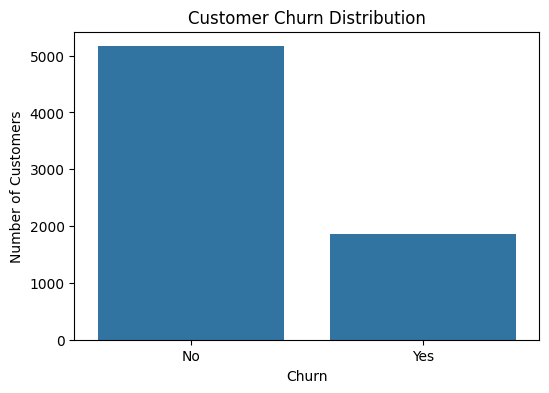

In [27]:
plt.figure(figsize=(6,4)) #data visulaziation
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
churn_percent = df["Churn"].value_counts(normalize=True) * 100
print(churn_percent)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


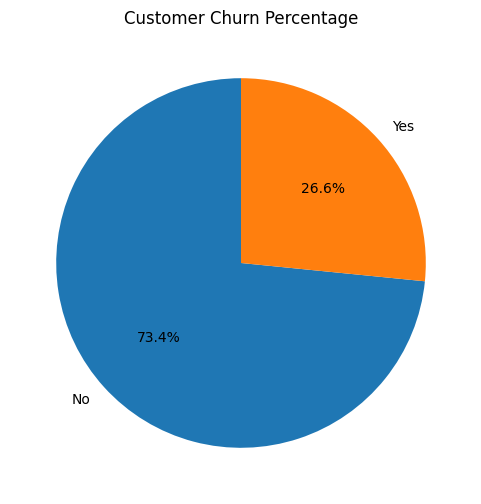

In [29]:
plt.figure(figsize=(6,6))

plt.pie(
    df["Churn"].value_counts(),
    labels=df["Churn"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

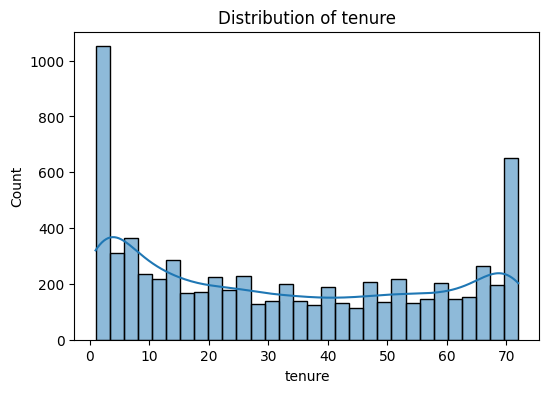

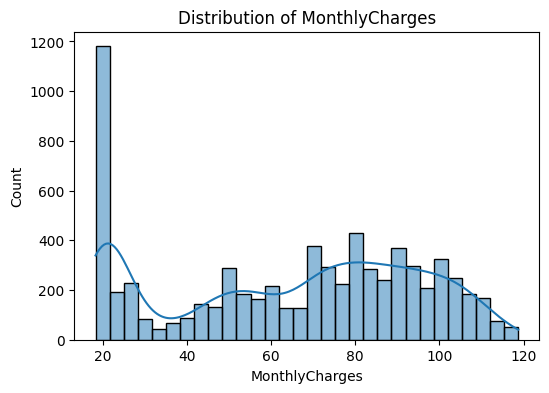

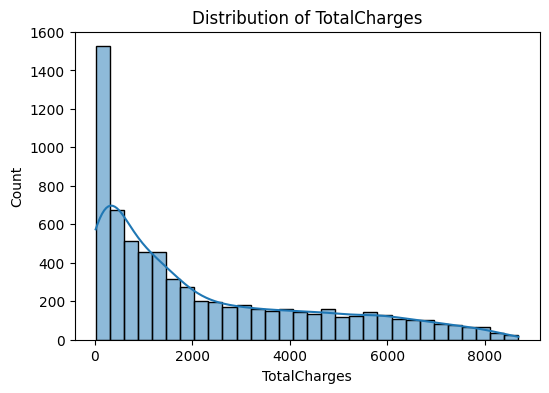

In [30]:
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f"Distribution of {col}")
    plt.show()

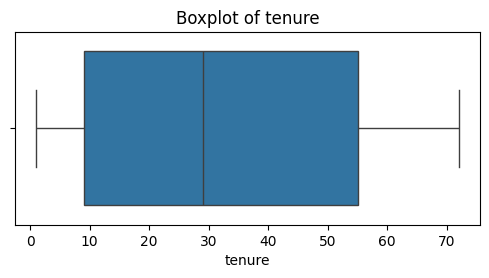

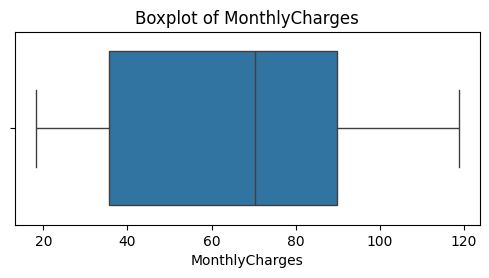

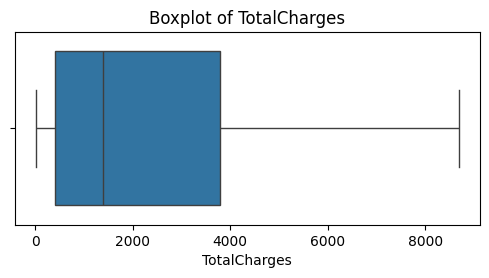

In [31]:
for col in numerical_cols:
    plt.figure(figsize=(6,2.5))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

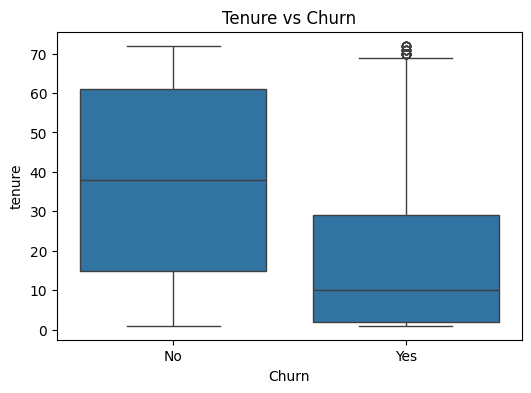

In [32]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")

plt.show()

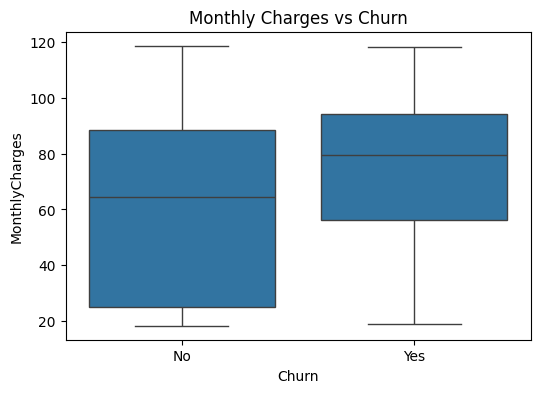

In [33]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

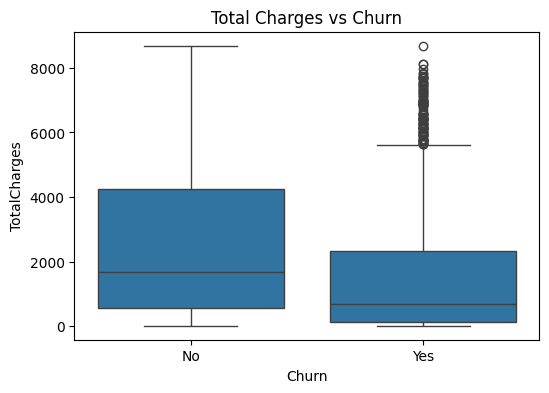

In [34]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="TotalCharges", data=df)

plt.title("Total Charges vs Churn")

plt.show()

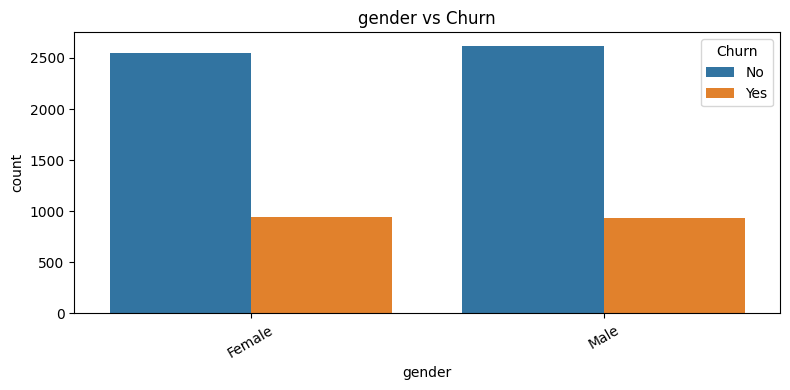

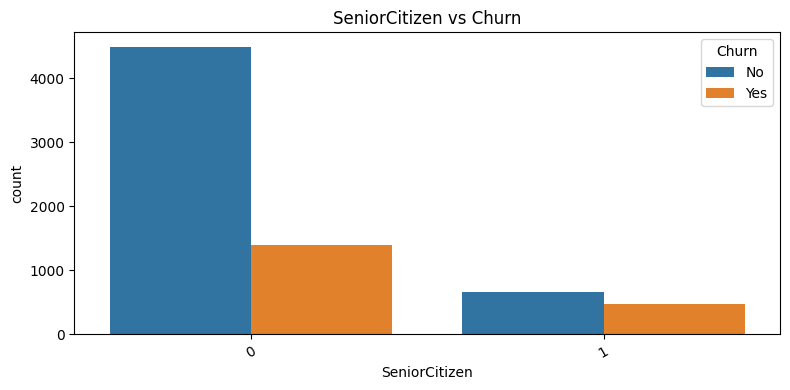

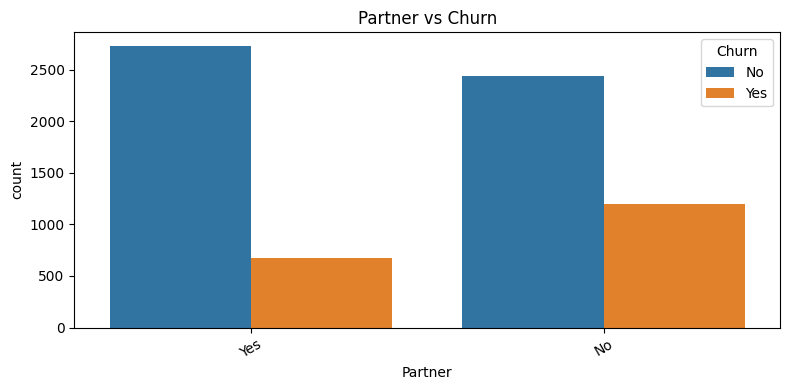

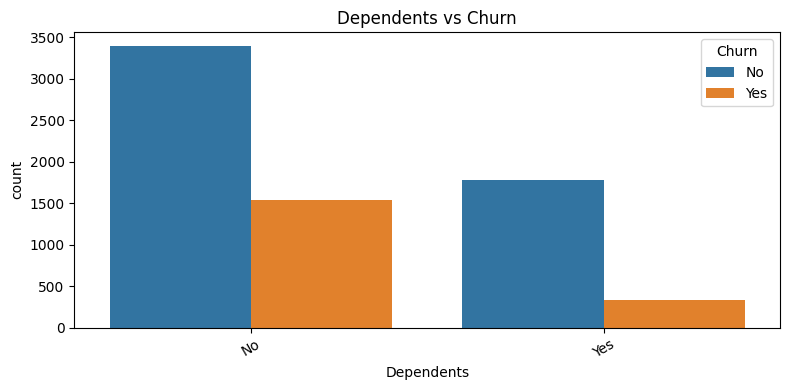

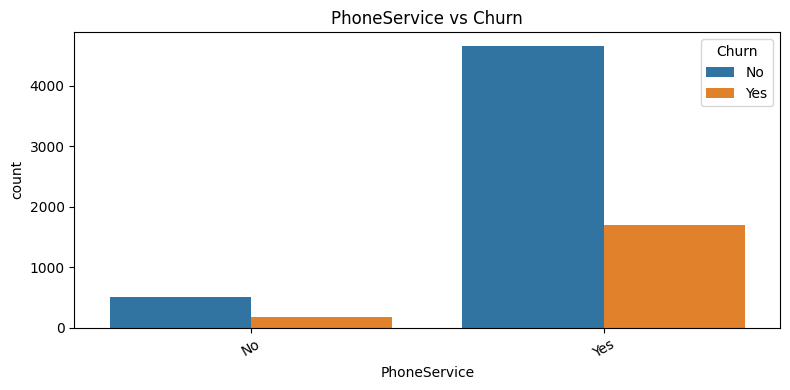

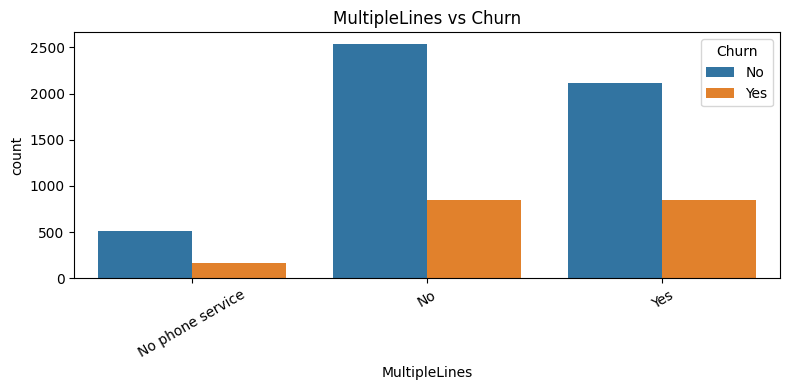

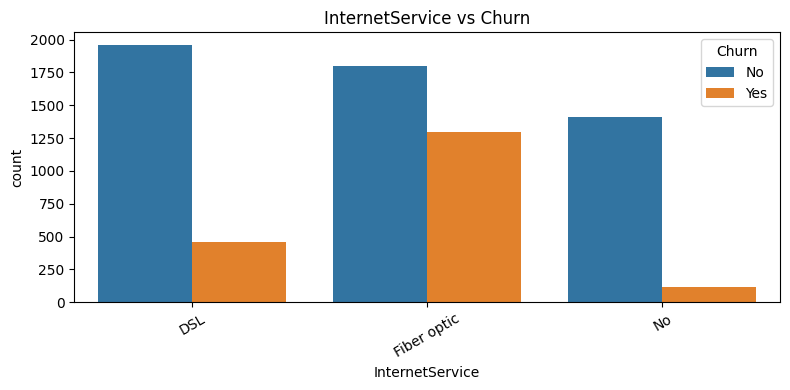

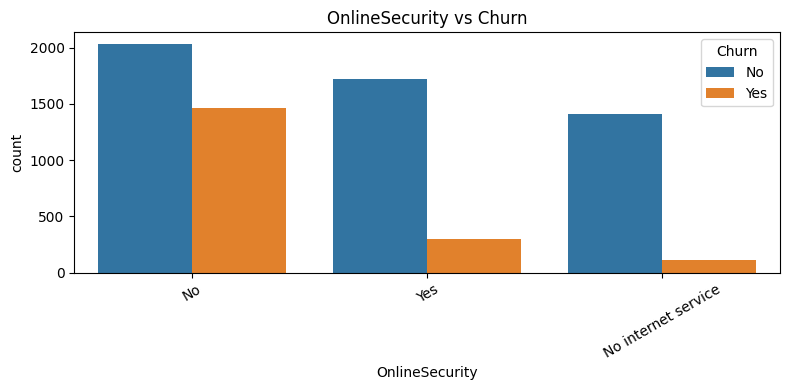

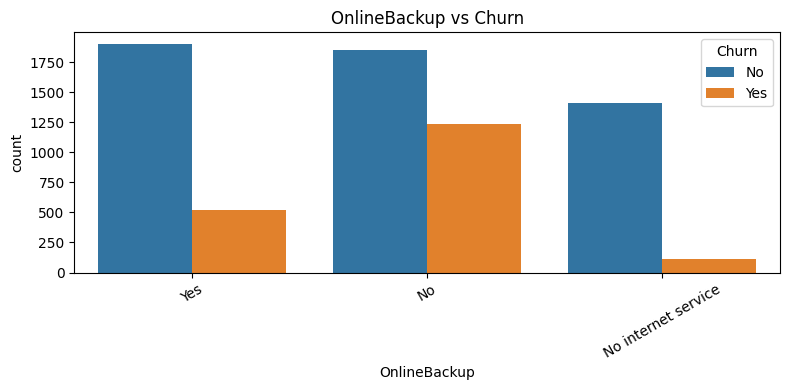

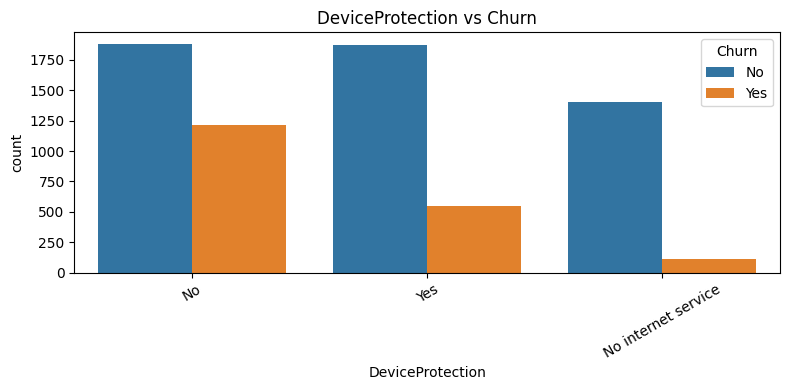

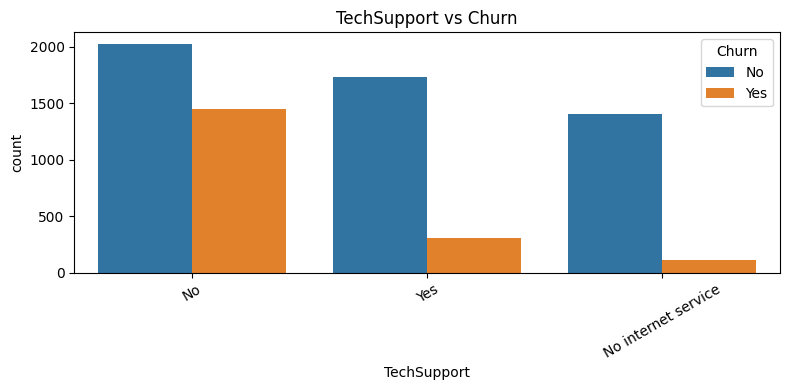

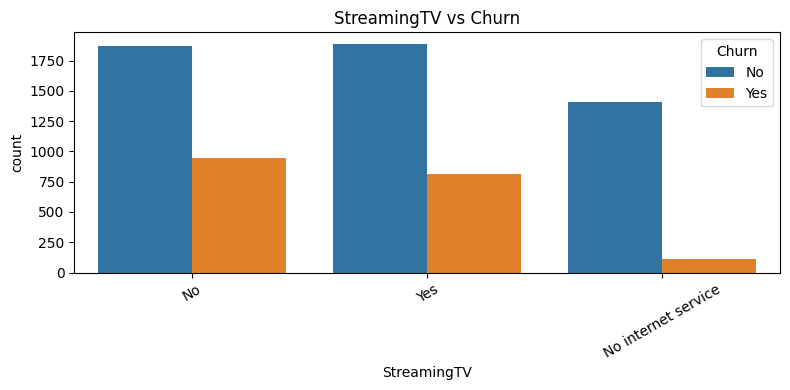

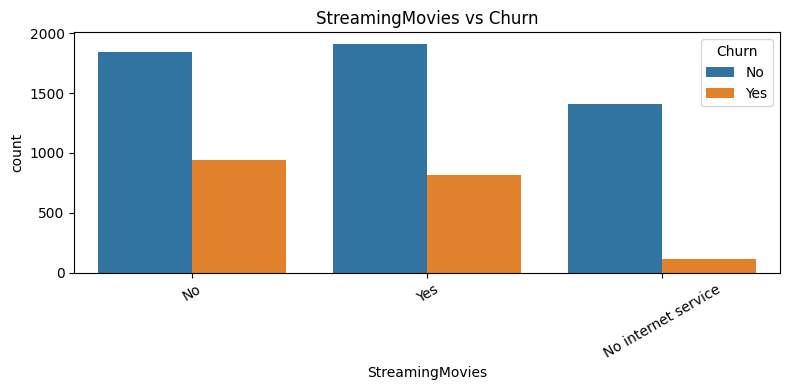

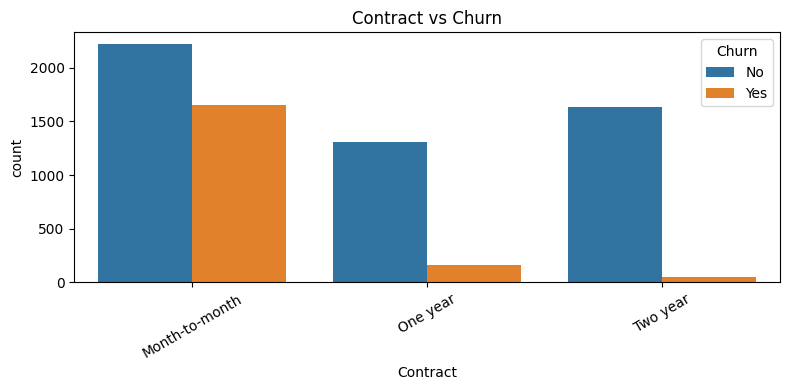

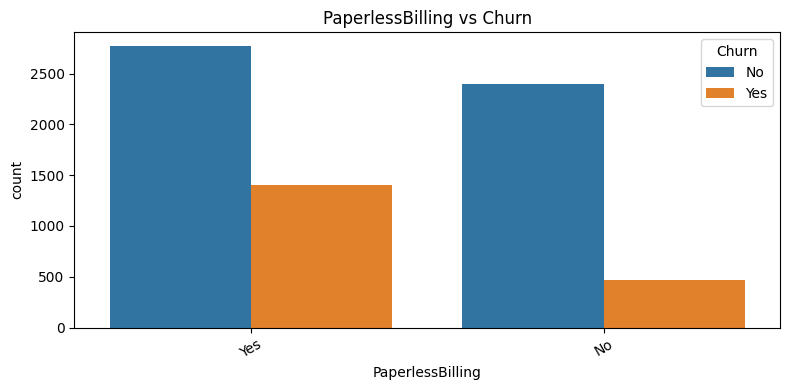

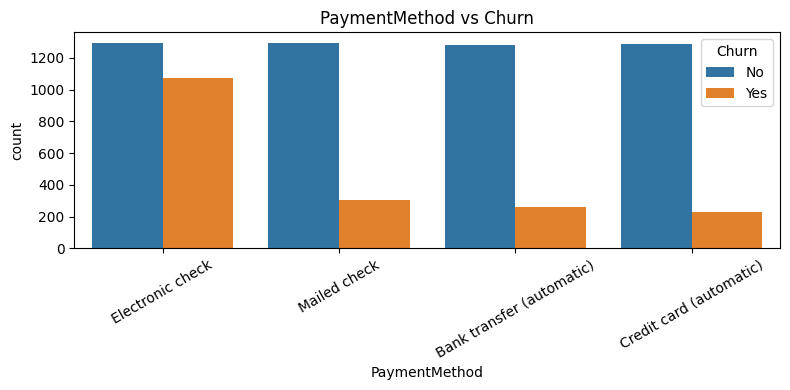

In [35]:
categorical_cols = ["gender","SeniorCitizen","Partner","Dependents","PhoneService",
    "MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod"]
for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(data=df, x=col, hue="Churn")

    plt.title(f"{col} vs Churn")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

In [36]:
print(df["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [37]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [38]:
corr_df = df.copy()


In [39]:
le = LabelEncoder()

for col in corr_df.columns:
    if corr_df[col].dtype == "string":
        corr_df[col] = le.fit_transform(corr_df[col])

In [40]:
corr_df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

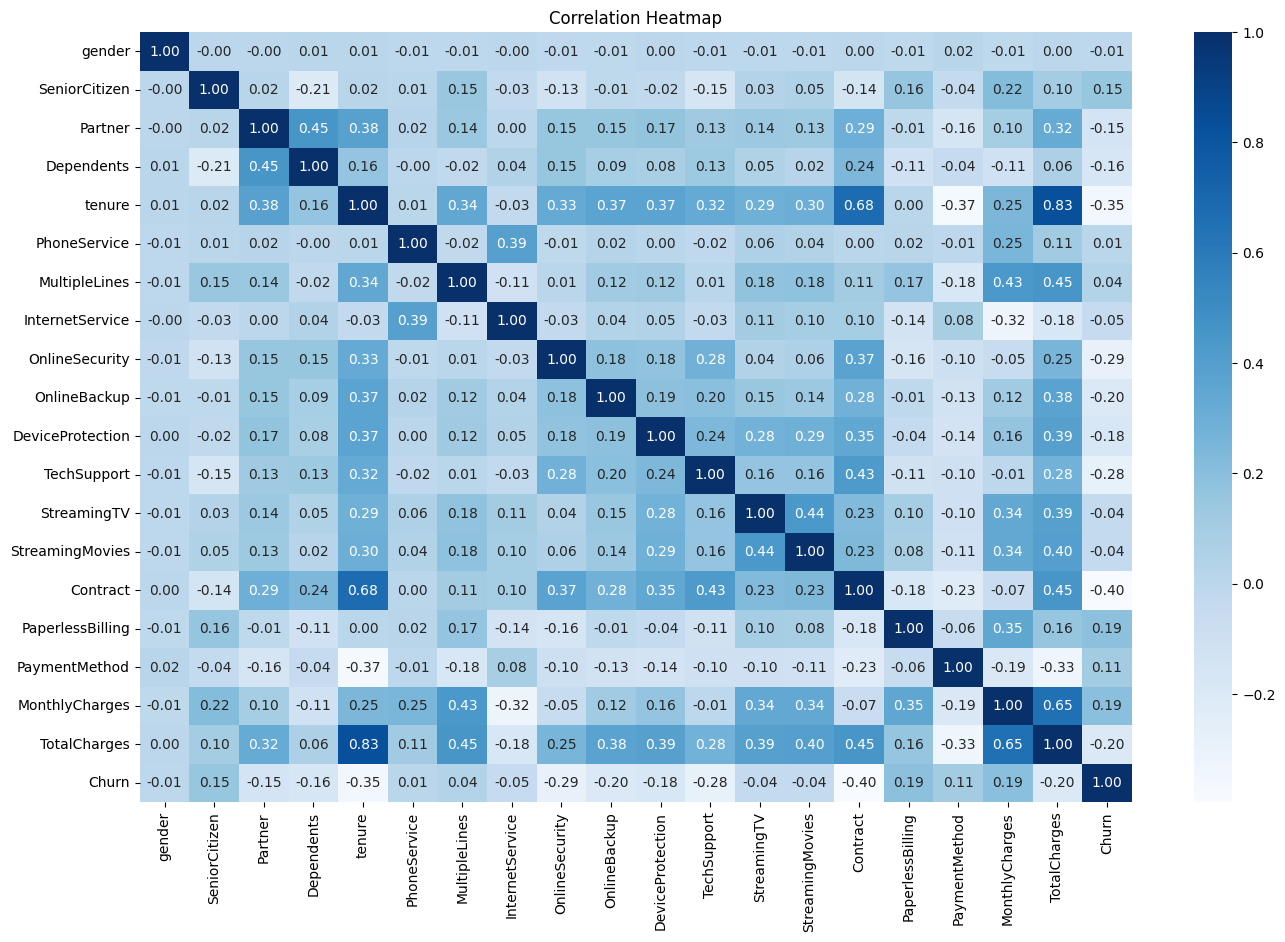

In [41]:
plt.figure(figsize=(16,10))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [42]:
corr_df.corr()["Churn"].sort_values(ascending=False)

Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
StreamingMovies    -0.038802
InternetService    -0.047097
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64

In [43]:
df_encoded = pd.get_dummies(df, drop_first=True) # as we need to apply 2 algo therfore for dscision tree we use actual dataset but for regression we use duplicate data set 

In [44]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [45]:
print(df_encoded.shape)

(7032, 31)


In [46]:
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
lr_model = LogisticRegression(random_state=42) # Logistic Regression model of Classfication =>Yes or No

lr_model.fit(X_train_scaled, y_train);

In [50]:
y_pred_lr = lr_model.predict(X_test_scaled)

Accuracy: 0.8038379530916845

              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1033
        True       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



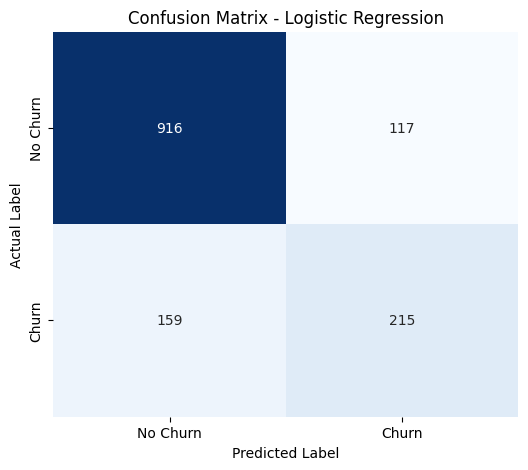

In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [52]:
dt_model = DecisionTreeClassifier(random_state=42) # Second Model for Evaluation
dt_model.fit(X_train, y_train);
y_pred_dt = dt_model.predict(X_test)

Accuracy: 0.7185501066098081

              precision    recall  f1-score   support

       False       0.81      0.81      0.81      1033
        True       0.47      0.46      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



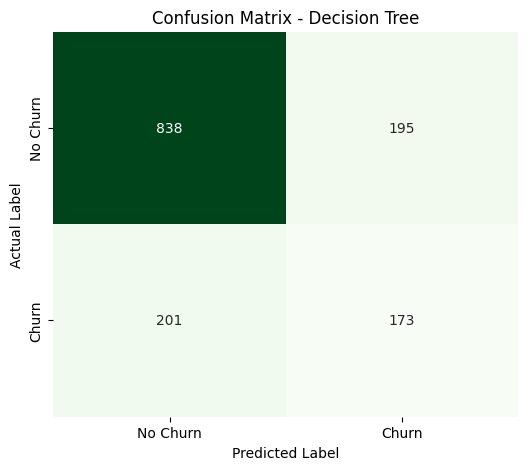

In [53]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print()
print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [54]:
dt_model = DecisionTreeClassifier(  # tuning model for better accurary
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print()

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7782515991471215

              precision    recall  f1-score   support

       False       0.85      0.84      0.85      1033
        True       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [56]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

In [57]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.443695
10,InternetService_Fiber optic,0.340678
3,TotalCharges,0.031653
28,PaymentMethod_Electronic check,0.026955
12,OnlineSecurity_No internet service,0.026924
2,MonthlyCharges,0.023394
25,Contract_Two year,0.020708
22,StreamingMovies_No internet service,0.015486
13,OnlineSecurity_Yes,0.015221
19,TechSupport_Yes,0.012226


In [58]:
top3 = feature_importance.head(3)

top3

,Feature,Importance
1,tenure,0.443695
10,InternetService_Fiber optic,0.340678
3,TotalCharges,0.031653


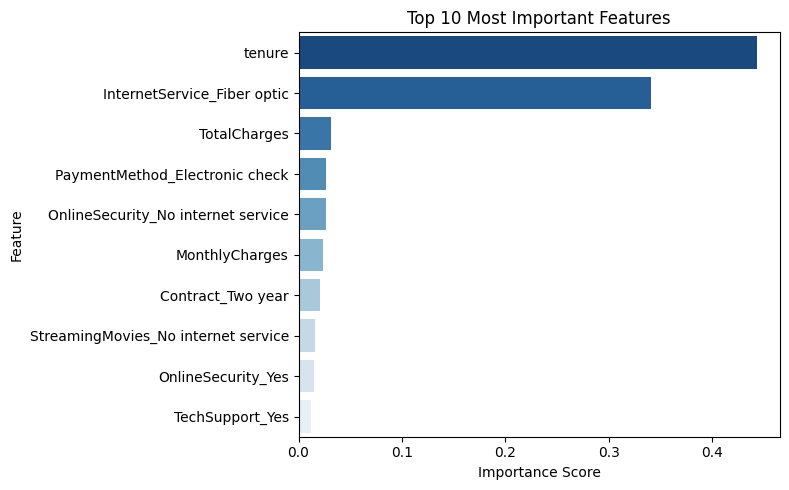

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [60]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.803838
1,Decision Tree,0.778252


In [61]:
# The analysis identified that customer tenure, fiber optic internet service, and total charges are the most influential factors associated with customer
# churn. Customers with shorter tenure and those using fiber optic internet services appear to have a higher likelihood of leaving the company, while
# total charges also play an important role in predicting churn. 
# By focusing on these high-risk customer groups, the company can introduce targeted retention strategies such as personalized offers, improved customer 
# support, and loyalty programs. Taking proactive action based on these insights can help reduce customer churn, improve customer satisfaction, and 
# protect long-term business revenue.

In [62]:
df_pipeline = df.copy()  # making copy for orginal data so that if result are not good then we are safed with orignal data 

In [63]:
X = df_pipeline.drop("Churn", axis=1)
y = df_pipeline["Churn"].map({"Yes": 1, "No": 0})  #x is for input while Y is output feature

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y) #Train and test split

In [65]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = X.select_dtypes(include=["string"]).columns.tolist()

#converting all columns having numerical value to numeric olumns and categorical data to second colum se we can use them in pipelines
print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [66]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols)
    ]
)

In [67]:

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42))
])

In [68]:
pipeline.fit(X_train, y_train)
y_pred_pipeline = pipeline.predict(X_test)

In [69]:
print("Pipeline Accuracy:", accuracy_score(y_test, y_pred_pipeline))

print()

print(classification_report(y_test, y_pred_pipeline))

Pipeline Accuracy: 0.8052594171997157

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



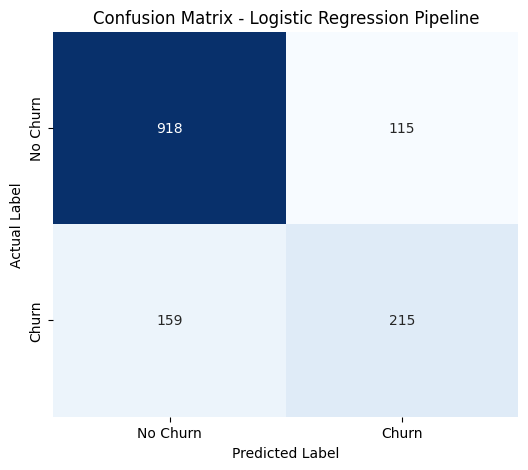

In [70]:
cm = confusion_matrix(y_test, y_pred_pipeline)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression Pipeline")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [71]:
manual_accuracy = accuracy_score(y_test, y_pred_lr)

pipeline_accuracy = accuracy_score(y_test, y_pred_pipeline)

print("Manual Logistic Regression:", manual_accuracy)
print("Pipeline Logistic Regression:", pipeline_accuracy)
print("Difference:", pipeline_accuracy - manual_accuracy)
#here we can see pipeline increse accuracy but only in points however its still matter

Manual Logistic Regression: 0.8038379530916845
Pipeline Logistic Regression: 0.8052594171997157
Difference: 0.001421464108031234


In [72]:

def engineer_features(data):
    data = data.copy()

    # Average amount spent per month
    data["AverageMonthlySpend"] = (
        data["TotalCharges"] / data["tenure"].replace(0, 1)
    )

    # Number of additional services
    service_cols = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    data["TotalServices"] = (
        data[service_cols]
        .apply(lambda x: (x == "Yes").sum(), axis=1)
    )

    return data

In [73]:
df_engineered = engineer_features(df_pipeline)

df_engineered[
    ["tenure", "TotalCharges", "AverageMonthlySpend", "TotalServices"]
].head()

,tenure,TotalCharges,AverageMonthlySpend,TotalServices
0,1,29.85,29.850000,1
1,34,1889.50,55.573529,2
2,2,108.15,54.075000,2
3,45,1840.75,40.905556,3
4,2,151.65,75.825000,0


In [74]:
print(df_engineered[["AverageMonthlySpend","TotalServices"]].describe())

       AverageMonthlySpend  TotalServices
count          7032.000000    7032.000000
mean             64.799424       2.038111
std              30.185891       1.847161
min              13.775000       0.000000
25%              36.179891       0.000000
50%              70.373239       2.000000
75%              90.179560       3.000000
max             121.400000       6.000000


In [75]:
numerical_cols_engineered = numerical_cols + [
    "AverageMonthlySpend",
    "TotalServices"
]
categorical_cols_engineered = categorical_cols

In [76]:
preprocessor_engineered = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols_engineered
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_cols_engineered
        )
    ]
)

In [77]:
feature_pipeline = Pipeline([
    (
        "feature_engineering",
        FunctionTransformer(engineer_features)
    ),
    (
        "preprocessor",
        preprocessor_engineered
    ),
    (
        "model",
        LogisticRegression(random_state=42)
    )
])

In [78]:
feature_pipeline.fit(X_train, y_train)
y_pred_feature = feature_pipeline.predict(X_test)
print(
    "Feature-Engineered Pipeline Accuracy:",
    accuracy_score(y_test, y_pred_feature)
)

print()

print(classification_report(y_test, y_pred_feature))

Feature-Engineered Pipeline Accuracy: 0.8031272210376688

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [79]:
comparison = pd.DataFrame({
    "Model": [
        "Manual Logistic Regression",
        "Basic Pipeline",
        "Feature-Engineered Pipeline"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_pipeline),
        accuracy_score(y_test, y_pred_feature)
    ]
})

comparison

,Model,Accuracy
0,Manual Logistic Regression,0.803838
1,Basic Pipeline,0.805259
2,Feature-Engineered Pipeline,0.803127


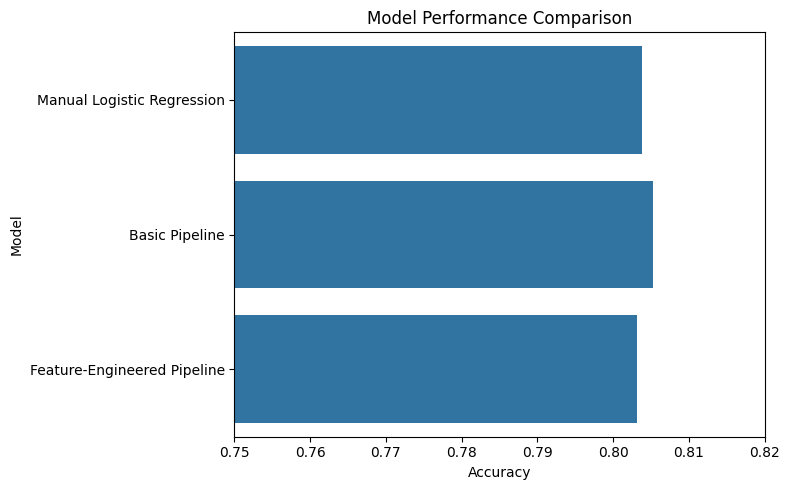

In [80]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Accuracy",
    y="Model"
)

plt.title("Model Performance Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0.75, 0.82)

plt.tight_layout()
plt.show()

In [81]:
#saving file with joblib librry 
joblib.dump(pipeline, "customer_churn_pipeline.pkl")
loaded_pipeline = joblib.load("customer_churn_pipeline.pkl")

loaded_predictions = loaded_pipeline.predict(X_test)

print(
    "Loaded Pipeline Accuracy:",
    accuracy_score(y_test, loaded_predictions)
)

Loaded Pipeline Accuracy: 0.8052594171997157
